# LAB 3 - Thermal Model of the Fire-Tube Boiler

This notebook is the executable version of the pre-report model requested in Section 6.1.1.

**What this notebook does**

- Loads an editable nominal parameter file.
- Models the boiler as an equivalent fire-tube shell-and-tube exchanger.
- Solves combustion, adiabatic flame temperature, heat transfer coefficients, overall conductance, water/fuel flow rates, and thermal balances.
- Generates the simplified geometry file required in the pre-report.
- Produces diagnostic plots and sensitivity graphs.

**Editing rule**

Change only the file `parametros_nominales_caldera.json` when you want to replace the nominal values with the real measurements from ML-041.


## 1. Imports and plotting style

The next cell imports the scientific libraries used by the model.  
Inline comments are intentionally written in English so that the code can be audited line by line.


In [1]:
# Import the JSON module to read the editable parameter file.
import json

# Import the math module for scalar mathematical operations.
import math

# Import Path to manipulate local file paths safely.
from pathlib import Path

# Import NumPy for numerical arrays and parameter sweeps.
import numpy as np

# Import pandas to display tables in a compact engineering format.
import pandas as pd

# Import matplotlib for all plots and for the simplified geometry drawing.
import matplotlib.pyplot as plt

# Import CoolProp to evaluate water and gas thermophysical properties.
from CoolProp.CoolProp import PropsSI

# Import Brent's method to solve the nonlinear temperature balances.
from scipy.optimize import brentq

# Configure a clean plotting style for the delivered notebook.
plt.style.use("seaborn-v0_8-whitegrid")

# Update fonts and default figure size so the exported plots remain readable.
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "font.size": 10
})

# Define the relative path of the editable parameter file.
PARAMETER_FILE = Path("parametros_nominales_caldera.json")

# Define the file names generated by the notebook.
GEOMETRY_PDF = Path("geometria_caldera_simplificada.pdf")
GEOMETRY_PNG = Path("geometria_caldera_simplificada.png")


## 2. Parameter loading

The notebook reads all nominal inputs from a single JSON file.  
This is the only file you need to edit when your measured dimensions and operating conditions are available.


In [2]:
# Open the editable nominal parameter file in text mode with UTF-8 encoding.
with PARAMETER_FILE.open("r", encoding="utf-8") as file:
    # Parse the JSON content and store it as a Python dictionary.
    parameters = json.load(file)

# Create short aliases for the three main parameter groups.
geometry = parameters["geometry"]
fuel = parameters["fuel"]
operation = parameters["operation"]

# Display the three parameter groups as a readable engineering table.
parameter_table = pd.DataFrame(
    [
        ("Shell inner diameter", "geometry.shell_inner_diameter_m", geometry["shell_inner_diameter_m"], "m"),
        ("Shell length", "geometry.shell_length_m", geometry["shell_length_m"], "m"),
        ("Furnace inner diameter", "geometry.furnace_inner_diameter_m", geometry["furnace_inner_diameter_m"], "m"),
        ("Furnace outer diameter", "geometry.furnace_outer_diameter_m", geometry["furnace_outer_diameter_m"], "m"),
        ("Return tube count", "geometry.return_tube_count", geometry["return_tube_count"], "-"),
        ("Return tube inner diameter", "geometry.return_tube_inner_diameter_m", geometry["return_tube_inner_diameter_m"], "m"),
        ("Return tube outer diameter", "geometry.return_tube_outer_diameter_m", geometry["return_tube_outer_diameter_m"], "m"),
        ("Return tube length", "geometry.return_tube_length_m", geometry["return_tube_length_m"], "m"),
        ("Useful heat target", "operation.useful_heat_output_w", operation["useful_heat_output_w"], "W"),
        ("Assumed boiler efficiency", "operation.overall_boiler_efficiency_assumed", operation["overall_boiler_efficiency_assumed"], "-"),
        ("Assumed exchanger efficiency", "operation.heat_exchanger_efficiency_assumed", operation["heat_exchanger_efficiency_assumed"], "-"),
        ("Excess air ratio", "operation.excess_air_ratio", operation["excess_air_ratio"], "-"),
        ("Water inlet temperature", "operation.water_inlet_temperature_c", operation["water_inlet_temperature_c"], "°C"),
        ("Steam outlet temperature", "operation.steam_outlet_temperature_c", operation["steam_outlet_temperature_c"], "°C"),
        ("Water inlet pressure", "operation.water_inlet_pressure_bar_abs", operation["water_inlet_pressure_bar_abs"], "bar abs"),
        ("Steam outlet pressure", "operation.steam_outlet_pressure_bar_abs", operation["steam_outlet_pressure_bar_abs"], "bar abs")
    ],
    columns=["Description", "Key", "Value", "Unit"]
)

# Show the parameter table.
parameter_table


,Description,Key,Value,Unit
0,Shell inner diameter,geometry.shell_inner_diameter_m,0.450,m
1,Shell length,geometry.shell_length_m,1.390,m
2,Furnace inner diameter,geometry.furnace_inner_diameter_m,0.200,m
3,Furnace outer diameter,geometry.furnace_outer_diameter_m,0.208,m
4,Return tube count,geometry.return_tube_count,22.000,-
5,Return tube inner diameter,geometry.return_tube_inner_diameter_m,0.030,m
6,Return tube outer diameter,geometry.return_tube_outer_diameter_m,0.034,m
7,Return tube length,geometry.return_tube_length_m,1.390,m
8,Useful heat target,operation.useful_heat_output_w,74570.000,W
9,Assumed boiler efficiency,operation.overall_boiler_efficiency_assumed,0.740,-


## 3. Thermodynamic and heat-transfer helper functions

The next code cell contains the full model.  
Each function has an explicit engineering role and an English docstring.


In [3]:
# Define universal constants used in the model.
SIGMA = 5.670374419e-8
G = 9.81
P_ATM = 101325.0

# Store molar masses in kg/mol for each species used in the combustion model.
MW = {
    "Methane": 0.016043,
    "Oxygen": 0.031998,
    "Nitrogen": 0.0280134,
    "CarbonDioxide": 0.0440095,
    "Water": 0.01801528,
}


def celsius_to_kelvin(temperature_c):
    '''Convert a temperature from degree Celsius to kelvin.'''
    return temperature_c + 273.15


def kelvin_to_celsius(temperature_k):
    '''Convert a temperature from kelvin to degree Celsius.'''
    return temperature_k - 273.15


def safe_lmtd(delta_t_1, delta_t_2):
    '''Return the logarithmic-mean temperature difference with basic validation.'''
    # Stop the calculation if any terminal temperature difference is non-physical.
    if delta_t_1 <= 0.0 or delta_t_2 <= 0.0:
        raise ValueError("LMTD is undefined because one terminal temperature difference is non-positive.")

    # Return the common limit when the two temperature differences are almost identical.
    if abs(delta_t_1 - delta_t_2) < 1e-12:
        return delta_t_1

    # Apply the standard logarithmic-mean temperature-difference equation.
    return (delta_t_1 - delta_t_2) / math.log(delta_t_1 / delta_t_2)


def methane_stoichiometry(excess_air_ratio):
    '''Return the molar reactant and product composition for methane combustion.'''
    # Guard against a substoichiometric case because this nominal model assumes complete combustion.
    if excess_air_ratio < 1.0:
        raise ValueError("The nominal model requires excess_air_ratio >= 1.0.")

    # Define the reactant and product dictionaries per mol of methane.
    reactants = {
        "Methane": 1.0,
        "Oxygen": 2.0 * excess_air_ratio,
        "Nitrogen": 7.52 * excess_air_ratio,
    }
    products = {
        "CarbonDioxide": 1.0,
        "Water": 2.0,
        "Oxygen": 2.0 * (excess_air_ratio - 1.0),
        "Nitrogen": 7.52 * excess_air_ratio,
    }

    # Return both dictionaries because they are needed in the combustion balances.
    return reactants, products


def sensible_molar_enthalpy(species, temperature_k):
    '''Return sensible molar enthalpy relative to 298.15 K.'''
    # Evaluate the absolute molar enthalpy at the requested temperature.
    absolute_enthalpy = PropsSI("Hmolar", "T", temperature_k, "P", P_ATM, species)

    # Evaluate the same property at the reference temperature.
    reference_enthalpy = PropsSI("Hmolar", "T", 298.15, "P", P_ATM, species)

    # Return the sensible contribution only.
    return absolute_enthalpy - reference_enthalpy


def mixture_sensible_enthalpy(species_amounts, temperature_k):
    '''Return total sensible enthalpy of a gas mixture per mol of fuel basis.'''
    # Multiply the sensible molar enthalpy of each species by its stoichiometric amount.
    return sum(
        moles * sensible_molar_enthalpy(species, temperature_k)
        for species, moles in species_amounts.items()
    )


def adiabatic_flame_temperature(lhv_j_kg, fuel_inlet_temperature_k, air_inlet_temperature_k, excess_air_ratio):
    '''Solve the methane-air adiabatic flame temperature from an enthalpy balance.'''
    # Build the stoichiometric reactant and product compositions.
    reactants, products = methane_stoichiometry(excess_air_ratio)

    # Convert the lower heating value from J/kg_fuel to J/mol_fuel.
    lhv_per_mol = lhv_j_kg * MW["Methane"]

    # Evaluate the sensible enthalpy brought by the inlet methane.
    methane_sensible = reactants["Methane"] * sensible_molar_enthalpy("Methane", fuel_inlet_temperature_k)

    # Evaluate the sensible enthalpy brought by the inlet oxygen.
    oxygen_sensible = reactants["Oxygen"] * sensible_molar_enthalpy("Oxygen", air_inlet_temperature_k)

    # Evaluate the sensible enthalpy brought by the inlet nitrogen.
    nitrogen_sensible = reactants["Nitrogen"] * sensible_molar_enthalpy("Nitrogen", air_inlet_temperature_k)

    # Sum all sensible inlet contributions.
    reactant_sensible = methane_sensible + oxygen_sensible + nitrogen_sensible

    # Define the nonlinear residual of the adiabatic enthalpy balance.
    def residual(temperature_k):
        return mixture_sensible_enthalpy(products, temperature_k) - (lhv_per_mol + reactant_sensible)

    # Solve for the adiabatic flame temperature inside a broad physically admissible interval.
    temperature_ad_k = brentq(residual, 800.0, 3200.0)

    # Return the solved temperature and the product composition.
    return temperature_ad_k, products


def fuel_mass_flow_rate(useful_heat_output_w, boiler_efficiency, lhv_j_kg):
    '''Back-calculate the nominal fuel flow from useful heat and boiler efficiency.'''
    return useful_heat_output_w / (boiler_efficiency * lhv_j_kg)


def product_mass_flow_rate(fuel_mass_flow_kg_s, product_species_amounts):
    '''Return the total product mass flow and the fuel molar flow rate.'''
    # Convert fuel mass flow to mol/s of methane.
    fuel_molar_flow_mol_s = fuel_mass_flow_kg_s / MW["Methane"]

    # Sum the product mass produced per mol of fuel and scale it by the molar fuel flow.
    product_mass_flow_kg_s = fuel_molar_flow_mol_s * sum(
        moles * MW[species] for species, moles in product_species_amounts.items()
    )

    # Return both rates because both are used later.
    return product_mass_flow_kg_s, fuel_molar_flow_mol_s


def flue_exit_temperature(q_transferred_w, fuel_molar_flow_mol_s, temperature_ad_k, product_species_amounts, minimum_exit_temperature_k):
    '''Solve the flue-gas exit temperature from the transferred heat rate.'''
    # Evaluate the mixture sensible enthalpy at the adiabatic flame temperature.
    hot_mixture_enthalpy = mixture_sensible_enthalpy(product_species_amounts, temperature_ad_k)

    # Convert the transferred heat rate into an enthalpy drop per mol of fuel.
    enthalpy_drop_required = q_transferred_w / fuel_molar_flow_mol_s

    # Define the residual of the flue-gas enthalpy balance.
    def residual(temperature_k):
        sensible_drop = hot_mixture_enthalpy - mixture_sensible_enthalpy(product_species_amounts, temperature_k)
        return sensible_drop - enthalpy_drop_required

    # Solve the exit temperature above the steam outlet temperature so LMTD remains physical.
    return brentq(residual, minimum_exit_temperature_k, temperature_ad_k - 1.0)


def water_enthalpy_states(water_inlet_temperature_k, water_inlet_pressure_pa, steam_outlet_temperature_k, steam_outlet_pressure_pa):
    '''Return water inlet enthalpy, outlet enthalpy, saturation temperature, and water flow rate.'''
    # Evaluate the compressed-liquid inlet enthalpy.
    h_in = PropsSI("H", "T", water_inlet_temperature_k, "P", water_inlet_pressure_pa, "Water")

    # Evaluate the saturation temperature at the outlet pressure.
    saturation_temperature_k = PropsSI("T", "P", steam_outlet_pressure_pa, "Q", 0, "Water")

    # Use the superheated outlet state if the specified outlet temperature is above saturation.
    if steam_outlet_temperature_k > saturation_temperature_k + 0.5:
        h_out = PropsSI("H", "T", steam_outlet_temperature_k, "P", steam_outlet_pressure_pa, "Water")
    else:
        # Fall back to saturated vapor if the outlet condition is near the saturation line.
        h_out = PropsSI("H", "P", steam_outlet_pressure_pa, "Q", 1, "Water")

    # Return all thermodynamic state data required by the nominal model.
    return h_in, h_out, saturation_temperature_k


def internal_gas_convection_coefficient(product_mass_flow_kg_s, gas_film_temperature_k, diameter_m, length_m, parallel_flow_channels):
    '''Return the internal gas-side convection coefficient using laminar or turbulent correlations.'''
    # Compute the total flow area available to the gas in the current zone.
    flow_area_m2 = parallel_flow_channels * math.pi * diameter_m ** 2 / 4.0

    # Evaluate gas properties using air as a surrogate for the combustion products.
    rho_g = PropsSI("D", "T", gas_film_temperature_k, "P", P_ATM, "Air")
    mu_g = PropsSI("VISCOSITY", "T", gas_film_temperature_k, "P", P_ATM, "Air")
    k_g = PropsSI("CONDUCTIVITY", "T", gas_film_temperature_k, "P", P_ATM, "Air")
    cp_g = PropsSI("CPMASS", "T", gas_film_temperature_k, "P", P_ATM, "Air")

    # Build the Prandtl number from the evaluated properties.
    pr_g = cp_g * mu_g / k_g

    # Compute mean gas velocity from mass conservation.
    velocity_g = product_mass_flow_kg_s / (rho_g * flow_area_m2)

    # Compute Reynolds number with the local hydraulic diameter.
    re_g = rho_g * velocity_g * diameter_m / mu_g

    # Use Hausen for laminar developing flow.
    if re_g < 2300.0:
        graetz = re_g * pr_g * diameter_m / length_m
        nu_g = 3.66 + (0.0668 * graetz) / (1.0 + 0.04 * graetz ** (2.0 / 3.0))
    else:
        # Use Petukhov's smooth-pipe friction factor approximation.
        friction_factor = (0.79 * math.log(re_g) - 1.64) ** -2

        # Use the classical Gnielinski correlation in the turbulent regime.
        nu_g = (
            (friction_factor / 8.0)
            * (re_g - 1000.0)
            * pr_g
            / (1.0 + 12.7 * math.sqrt(friction_factor / 8.0) * (pr_g ** (2.0 / 3.0) - 1.0))
        )

    # Convert the Nusselt number into a convection coefficient.
    h_g = nu_g * k_g / diameter_m

    # Return the heat-transfer coefficient and the most relevant dimensionless groups.
    return {
        "h_w_m2k": h_g,
        "re": re_g,
        "pr": pr_g,
        "nu": nu_g,
        "velocity_m_s": velocity_g,
        "rho_kg_m3": rho_g,
    }


def linearized_radiation_coefficient(hot_gas_temperature_k, wall_temperature_k, emissivity):
    '''Return a linearized radiation coefficient between hot gas and wall.'''
    return emissivity * SIGMA * (hot_gas_temperature_k + wall_temperature_k) * (
        hot_gas_temperature_k ** 2 + wall_temperature_k ** 2
    )


def churchill_chu_horizontal_cylinder(bulk_temperature_k, bulk_pressure_pa, wall_superheat_k, outer_diameter_m):
    '''Return the natural-convection coefficient around a horizontal cylinder.'''
    # Evaluate film temperature between the water bulk and the external wall.
    film_temperature_k = bulk_temperature_k + 0.5 * wall_superheat_k

    # Evaluate water properties at the film temperature.
    rho_w = PropsSI("D", "T", film_temperature_k, "P", bulk_pressure_pa, "Water")
    mu_w = PropsSI("VISCOSITY", "T", film_temperature_k, "P", bulk_pressure_pa, "Water")
    k_w = PropsSI("CONDUCTIVITY", "T", film_temperature_k, "P", bulk_pressure_pa, "Water")
    cp_w = PropsSI("CPMASS", "T", film_temperature_k, "P", bulk_pressure_pa, "Water")
    beta_w = PropsSI("ISOBARIC_EXPANSION_COEFFICIENT", "T", film_temperature_k, "P", bulk_pressure_pa, "Water")

    # Build the kinematic viscosity and thermal diffusivity.
    nu_w = mu_w / rho_w
    alpha_w = k_w / (rho_w * cp_w)

    # Compute Prandtl and Rayleigh numbers.
    pr_w = nu_w / alpha_w
    ra_w = G * beta_w * wall_superheat_k * outer_diameter_m ** 3 / (nu_w * alpha_w)

    # Apply the Churchill-Chu correlation for horizontal cylinders.
    nu_w_mean = (
        0.60
        + (0.387 * ra_w ** (1.0 / 6.0))
        / ((1.0 + (0.559 / pr_w) ** (9.0 / 16.0)) ** (8.0 / 27.0))
    ) ** 2

    # Convert Nusselt number to convection coefficient.
    h_w = nu_w_mean * k_w / outer_diameter_m

    # Return the coefficient and supporting dimensionless groups.
    return {
        "h_w_m2k": h_w,
        "ra": ra_w,
        "pr": pr_w,
        "nu": nu_w_mean,
    }


def overall_u_outside_basis(fire_side_h_w_m2k, water_side_h_w_m2k, inner_diameter_m, outer_diameter_m, wall_conductivity_w_mk):
    '''Return the overall conductance coefficient using the external area basis.'''
    return 1.0 / (
        1.0 / water_side_h_w_m2k
        + outer_diameter_m * math.log(outer_diameter_m / inner_diameter_m) / (2.0 * wall_conductivity_w_mk)
        + outer_diameter_m / (inner_diameter_m * fire_side_h_w_m2k)
    )


def draw_geometry(geometry_data, output_pdf, output_png):
    '''Draw a simplified front view and longitudinal equivalent of the nominal boiler.'''
    # Create a figure with two panels so the front and side views can be shown together.
    figure, axes = plt.subplots(1, 2, figsize=(11, 5))

    # ------------------------------------------------------------------
    # Front view
    # ------------------------------------------------------------------
    front_axis = axes[0]
    front_axis.set_title("Front view")
    front_axis.set_aspect("equal")

    # Draw the shell inner boundary as the largest circle.
    shell_radius = geometry_data["shell_inner_diameter_m"] / 2.0
    shell_circle = plt.Circle((0.0, 0.0), shell_radius, fill=False, linewidth=2.0, color="black")
    front_axis.add_patch(shell_circle)

    # Draw the furnace tube at the center.
    furnace_radius = geometry_data["furnace_outer_diameter_m"] / 2.0
    furnace_circle = plt.Circle((0.0, 0.0), furnace_radius, fill=False, linewidth=2.0, color="firebrick")
    front_axis.add_patch(furnace_circle)

    # Place the return tubes on two lateral arcs so the bank follows the shell radius
    # and avoids overlapping with the central furnace, matching the real boiler front view.
    tube_radius = geometry_data["return_tube_outer_diameter_m"] / 2.0
    inner_arc_radius = geometry_data.get("front_view_inner_arc_radius_m", 0.125)
    outer_arc_radius = geometry_data.get("front_view_outer_arc_radius_m", 0.165)
    inner_arc_angles_left_deg = np.linspace(125.0, 235.0, 5)
    outer_arc_angles_left_deg = np.linspace(130.0, 230.0, 6)
    inner_arc_angles_right_deg = np.linspace(55.0, -55.0, 5)
    outer_arc_angles_right_deg = np.linspace(50.0, -50.0, 6)

    for angle_deg in inner_arc_angles_left_deg:
        angle_rad = np.deg2rad(angle_deg)
        x_center = inner_arc_radius * np.cos(angle_rad)
        y_center = inner_arc_radius * np.sin(angle_rad)
        front_axis.add_patch(
            plt.Circle((x_center, y_center), tube_radius, fill=False, linewidth=1.4, color="navy")
        )

    for angle_deg in outer_arc_angles_left_deg:
        angle_rad = np.deg2rad(angle_deg)
        x_center = outer_arc_radius * np.cos(angle_rad)
        y_center = outer_arc_radius * np.sin(angle_rad)
        front_axis.add_patch(
            plt.Circle((x_center, y_center), tube_radius, fill=False, linewidth=1.4, color="navy")
        )

    for angle_deg in inner_arc_angles_right_deg:
        angle_rad = np.deg2rad(angle_deg)
        x_center = inner_arc_radius * np.cos(angle_rad)
        y_center = inner_arc_radius * np.sin(angle_rad)
        front_axis.add_patch(
            plt.Circle((x_center, y_center), tube_radius, fill=False, linewidth=1.4, color="navy")
        )

    for angle_deg in outer_arc_angles_right_deg:
        angle_rad = np.deg2rad(angle_deg)
        x_center = outer_arc_radius * np.cos(angle_rad)
        y_center = outer_arc_radius * np.sin(angle_rad)
        front_axis.add_patch(
            plt.Circle((x_center, y_center), tube_radius, fill=False, linewidth=1.4, color="navy")
        )

    # Add front-view labels.
    front_axis.text(0.0, 0.0, "Furnace", ha="center", va="center", fontsize=9, color="firebrick")
    front_axis.text(0.0, shell_radius + 0.02, "Shell", ha="center", va="bottom", fontsize=9)
    front_axis.set_xlim(-0.30, 0.30)
    front_axis.set_ylim(-0.30, 0.30)
    front_axis.set_xlabel("x [m]")
    front_axis.set_ylabel("y [m]")

    # ------------------------------------------------------------------
    # Longitudinal view
    # ------------------------------------------------------------------
    side_axis = axes[1]
    side_axis.set_title("Longitudinal equivalent")

    # Extract longitudinal dimensions for simpler notation.
    length = geometry_data["shell_length_m"]
    shell_height = geometry_data["shell_inner_diameter_m"]
    furnace_height = geometry_data["furnace_outer_diameter_m"]
    tube_height = geometry_data["return_tube_outer_diameter_m"]

    # Draw the shell envelope.
    side_axis.add_patch(plt.Rectangle((0.0, 0.0), length, shell_height, fill=False, linewidth=2.0, color="black"))

    # Draw the furnace pass in the upper half.
    side_axis.add_patch(
        plt.Rectangle(
            (0.0, 0.55 * shell_height - furnace_height / 2.0),
            length,
            furnace_height,
            fill=False,
            linewidth=2.0,
            color="firebrick",
        )
    )

    # Draw the return-tube bank in the lower half as a compact equivalent.
    return_bank_y = 0.18 * shell_height
    for row_index in range(4):
        side_axis.add_patch(
            plt.Rectangle(
                (0.05 * length, return_bank_y + row_index * 0.045),
                0.90 * length,
                tube_height,
                fill=False,
                linewidth=1.2,
                color="navy",
            )
        )

    # Add qualitative flow arrows.
    side_axis.annotate("", xy=(0.92 * length, 0.72 * shell_height), xytext=(0.08 * length, 0.72 * shell_height),
                       arrowprops=dict(arrowstyle="->", lw=1.8, color="firebrick"))
    side_axis.annotate("", xy=(0.08 * length, 0.25 * shell_height), xytext=(0.92 * length, 0.25 * shell_height),
                       arrowprops=dict(arrowstyle="->", lw=1.8, color="navy"))

    # Annotate the two gas passes.
    side_axis.text(0.15 * length, 0.79 * shell_height, "Pass 1: central furnace", color="firebrick")
    side_axis.text(0.55 * length, 0.07 * shell_height, "Pass 2: symmetric lateral return tubes", color="navy", ha="center")
    side_axis.set_xlim(-0.02, length + 0.02)
    side_axis.set_ylim(-0.02, shell_height + 0.02)
    side_axis.set_xlabel("z [m]")
    side_axis.set_ylabel("Equivalent section [m]")

    # Tighten layout before exporting.
    figure.tight_layout()

    # Save the figure in PDF and PNG format for the report and preview.
    figure.savefig(output_pdf, bbox_inches="tight")
    figure.savefig(output_png, dpi=200, bbox_inches="tight")

    # Return the figure object so the caller can still display it inline.
    return figure


def solve_nominal_case(parameter_dictionary):
    '''Solve the full nominal boiler model and return a nested results dictionary.'''
    # Extract the three parameter groups.
    geometry_data = parameter_dictionary["geometry"]
    fuel_data = parameter_dictionary["fuel"]
    operation_data = parameter_dictionary["operation"]

    # Convert the relevant temperatures to kelvin.
    fuel_inlet_k = celsius_to_kelvin(operation_data["fuel_inlet_temperature_c"])
    air_inlet_k = celsius_to_kelvin(operation_data["air_inlet_temperature_c"])
    water_inlet_k = celsius_to_kelvin(operation_data["water_inlet_temperature_c"])
    steam_outlet_k = celsius_to_kelvin(operation_data["steam_outlet_temperature_c"])
    furnace_wall_k = celsius_to_kelvin(operation_data["furnace_wall_temperature_c_guess"])
    return_wall_k = celsius_to_kelvin(operation_data["return_tube_wall_temperature_c_guess"])

    # Convert the two pressures from bar absolute to pascal.
    water_inlet_pressure_pa = operation_data["water_inlet_pressure_bar_abs"] * 1.0e5
    steam_outlet_pressure_pa = operation_data["steam_outlet_pressure_bar_abs"] * 1.0e5

    # Solve the nominal fuel consumption from the useful heat target.
    fuel_flow_kg_s = fuel_mass_flow_rate(
        operation_data["useful_heat_output_w"],
        operation_data["overall_boiler_efficiency_assumed"],
        fuel_data["lower_heating_value_j_kg"],
    )

    # Compute the chemical heat-release rate.
    q_comb_w = fuel_flow_kg_s * fuel_data["lower_heating_value_j_kg"]

    # Compute the nominal heat transferred from combustion gas to the exchanger surfaces.
    q_trans_w = q_comb_w * operation_data["heat_exchanger_efficiency_assumed"]

    # Solve the adiabatic flame temperature and product composition.
    temperature_ad_k, products = adiabatic_flame_temperature(
        fuel_data["lower_heating_value_j_kg"],
        fuel_inlet_k,
        air_inlet_k,
        operation_data["excess_air_ratio"],
    )

    # Compute product mass flow and fuel molar flow.
    product_flow_kg_s, fuel_molar_flow_mol_s = product_mass_flow_rate(fuel_flow_kg_s, products)

    # Solve the flue-gas exit temperature from the transferred heat duty.
    flue_exit_k = flue_exit_temperature(
        q_trans_w,
        fuel_molar_flow_mol_s,
        temperature_ad_k,
        products,
        steam_outlet_k + 5.0,
    )

    # Evaluate water-side inlet and outlet enthalpies.
    h_in_j_kg, h_out_j_kg, saturation_temperature_k = water_enthalpy_states(
        water_inlet_k,
        water_inlet_pressure_pa,
        steam_outlet_k,
        steam_outlet_pressure_pa,
    )

    # Compute water flow from the useful heat target.
    water_flow_kg_s = operation_data["useful_heat_output_w"] / (h_out_j_kg - h_in_j_kg)

    # Build a representative gas-film temperature.
    gas_film_temperature_k = 0.5 * (temperature_ad_k + flue_exit_k)

    # Evaluate gas-side convection in the furnace zone.
    furnace_gas = internal_gas_convection_coefficient(
        product_flow_kg_s,
        gas_film_temperature_k,
        geometry_data["furnace_inner_diameter_m"],
        geometry_data["shell_length_m"],
        parallel_flow_channels=1,
    )

    # Evaluate gas-side convection in the return-tube bank.
    return_gas = internal_gas_convection_coefficient(
        product_flow_kg_s,
        gas_film_temperature_k,
        geometry_data["return_tube_inner_diameter_m"],
        geometry_data["return_tube_length_m"],
        parallel_flow_channels=geometry_data["return_tube_count"],
    )

    # Evaluate the linearized fire-side radiation in the furnace pass.
    h_rad_furnace = linearized_radiation_coefficient(
        gas_film_temperature_k,
        furnace_wall_k,
        operation_data["furnace_emissivity_assumed"],
    )

    # Evaluate the linearized fire-side radiation in the return-tube pass.
    h_rad_return = linearized_radiation_coefficient(
        gas_film_temperature_k,
        return_wall_k,
        operation_data["return_tube_emissivity_assumed"],
    )

    # Build a representative shell-side bulk temperature between inlet water and saturation.
    water_bulk_temperature_k = 0.5 * (water_inlet_k + saturation_temperature_k)

    # Evaluate natural convection around the furnace.
    furnace_water = churchill_chu_horizontal_cylinder(
        water_bulk_temperature_k,
        steam_outlet_pressure_pa,
        operation_data["water_side_wall_superheat_k"],
        geometry_data["furnace_outer_diameter_m"],
    )

    # Evaluate natural convection around the return tubes.
    return_water = churchill_chu_horizontal_cylinder(
        water_bulk_temperature_k,
        steam_outlet_pressure_pa,
        operation_data["water_side_wall_superheat_k"],
        geometry_data["return_tube_outer_diameter_m"],
    )

    # Sum convection and radiation to form the effective fire-side coefficient in each zone.
    h_fire_furnace = furnace_gas["h_w_m2k"] + h_rad_furnace
    h_fire_return = return_gas["h_w_m2k"] + h_rad_return

    # Evaluate the overall outside-basis conductance coefficient in the furnace zone.
    u_furnace = overall_u_outside_basis(
        h_fire_furnace,
        furnace_water["h_w_m2k"],
        geometry_data["furnace_inner_diameter_m"],
        geometry_data["furnace_outer_diameter_m"],
        geometry_data["tube_wall_thermal_conductivity_w_mk"],
    )

    # Evaluate the overall outside-basis conductance coefficient in the return-tube zone.
    u_return = overall_u_outside_basis(
        h_fire_return,
        return_water["h_w_m2k"],
        geometry_data["return_tube_inner_diameter_m"],
        geometry_data["return_tube_outer_diameter_m"],
        geometry_data["tube_wall_thermal_conductivity_w_mk"],
    )

    # Compute the two zone transfer areas.
    area_furnace_m2 = math.pi * geometry_data["furnace_outer_diameter_m"] * geometry_data["shell_length_m"]
    area_return_m2 = (
        geometry_data["return_tube_count"]
        * math.pi
        * geometry_data["return_tube_outer_diameter_m"]
        * geometry_data["return_tube_length_m"]
    )

    # Sum both conductances into a single total UA value.
    ua_total_w_k = u_furnace * area_furnace_m2 + u_return * area_return_m2

    # Evaluate the terminal temperature differences required by LMTD.
    delta_t_1_k = temperature_ad_k - water_inlet_k
    delta_t_2_k = flue_exit_k - steam_outlet_k
    lmtd_k = safe_lmtd(delta_t_1_k, delta_t_2_k)

    # Predict the heat rate justified by the conductance network.
    q_ua_w = ua_total_w_k * lmtd_k

    # Estimate the post-transfer thermal losses.
    q_post_w = q_trans_w - operation_data["useful_heat_output_w"]

    # Estimate the stack loss as the difference between combustion heat and transferred heat.
    q_stack_w = q_comb_w - q_trans_w

    # Compute the dry-basis combustion products to compare with gas-analyzer expectations.
    dry_products = {key: value for key, value in products.items() if key != "Water"}
    dry_total = sum(dry_products.values())
    dry_mole_fractions = {key: value / dry_total for key, value in dry_products.items()}

    # Store all relevant results in a nested dictionary.
    return {
        "combustion": {
            "t_ad_k": temperature_ad_k,
            "t_ad_c": kelvin_to_celsius(temperature_ad_k),
            "t_flue_out_k": flue_exit_k,
            "t_flue_out_c": kelvin_to_celsius(flue_exit_k),
            "fuel_mass_flow_kg_s": fuel_flow_kg_s,
            "fuel_mass_flow_kg_h": fuel_flow_kg_s * 3600.0,
            "product_mass_flow_kg_s": product_flow_kg_s,
            "product_mass_flow_kg_h": product_flow_kg_s * 3600.0,
            "products_mol_per_mol_fuel": products,
            "dry_products_mole_fraction": dry_mole_fractions,
        },
        "water": {
            "h_in_j_kg": h_in_j_kg,
            "h_out_j_kg": h_out_j_kg,
            "water_mass_flow_kg_s": water_flow_kg_s,
            "water_mass_flow_kg_h": water_flow_kg_s * 3600.0,
            "t_saturation_c": kelvin_to_celsius(saturation_temperature_k),
            "water_inlet_temperature_c": operation_data["water_inlet_temperature_c"],
            "steam_outlet_temperature_c": operation_data["steam_outlet_temperature_c"],
        },
        "heat_transfer": {
            "furnace_area_m2": area_furnace_m2,
            "return_area_m2": area_return_m2,
            "total_area_m2": area_furnace_m2 + area_return_m2,
            "u_furnace_w_m2k": u_furnace,
            "u_return_w_m2k": u_return,
            "ua_total_w_k": ua_total_w_k,
            "lmtd_k": lmtd_k,
            "delta_t_1_k": delta_t_1_k,
            "delta_t_2_k": delta_t_2_k,
            "q_ua_w": q_ua_w,
            "consistency_ratio": q_ua_w / q_trans_w,
        },
        "coefficients": {
            "furnace_gas_convection_w_m2k": furnace_gas["h_w_m2k"],
            "return_gas_convection_w_m2k": return_gas["h_w_m2k"],
            "furnace_radiation_w_m2k": h_rad_furnace,
            "return_radiation_w_m2k": h_rad_return,
            "furnace_water_convection_w_m2k": furnace_water["h_w_m2k"],
            "return_water_convection_w_m2k": return_water["h_w_m2k"],
            "furnace_re": furnace_gas["re"],
            "return_re": return_gas["re"],
            "furnace_ra": furnace_water["ra"],
            "return_ra": return_water["ra"],
        },
        "performance": {
            "q_useful_w": operation_data["useful_heat_output_w"],
            "q_comb_w": q_comb_w,
            "q_trans_w": q_trans_w,
            "q_post_w": q_post_w,
            "q_stack_w": q_stack_w,
            "boiler_efficiency_assumed": operation_data["overall_boiler_efficiency_assumed"],
            "exchanger_efficiency_assumed": operation_data["heat_exchanger_efficiency_assumed"],
        },
    }


## 4. Nominal solution

The next cell runs the full model and creates compact result tables.  
The notebook output is the nominal reference that you should compare later against your experimental values.


In [4]:
# Solve the complete nominal case using the editable parameter dictionary.
results = solve_nominal_case(parameters)

# Build a compact summary table with the variables most likely to appear in the pre-report.
summary_table = pd.DataFrame(
    [
        ("Adiabatic flame temperature", results["combustion"]["t_ad_c"], "°C"),
        ("Flue-gas exit temperature", results["combustion"]["t_flue_out_c"], "°C"),
        ("Fuel mass flow", results["combustion"]["fuel_mass_flow_kg_h"], "kg/h"),
        ("Water mass flow", results["water"]["water_mass_flow_kg_h"], "kg/h"),
        ("Furnace overall U", results["heat_transfer"]["u_furnace_w_m2k"], "W/m²-K"),
        ("Return-bank overall U", results["heat_transfer"]["u_return_w_m2k"], "W/m²-K"),
        ("Total transfer area", results["heat_transfer"]["total_area_m2"], "m²"),
        ("Total UA", results["heat_transfer"]["ua_total_w_k"], "W/K"),
        ("Heat justified by UA", results["heat_transfer"]["q_ua_w"] / 1000.0, "kW"),
        ("Nominal transferred heat", results["performance"]["q_trans_w"] / 1000.0, "kW"),
        ("UA consistency ratio", results["heat_transfer"]["consistency_ratio"], "-"),
        ("Theoretical N2 dry basis", 100.0 * results["combustion"]["dry_products_mole_fraction"]["Nitrogen"], "%")
    ],
    columns=["Variable", "Value", "Unit"]
)

# Round the table for cleaner presentation in the notebook.
summary_table["Value"] = summary_table["Value"].map(lambda value: round(value, 4))

# Display the summary table.
summary_table


,Variable,Value,Unit
0,Adiabatic flame temperature,1635.1372,°C
1,Flue-gas exit temperature,217.1246,°C
2,Fuel mass flow,7.9381,kg/h
3,Water mass flow,99.2665,kg/h
4,Furnace overall U,49.6156,W/m²-K
5,Return-bank overall U,49.2374,W/m²-K
6,Total transfer area,4.1747,m²
7,Total UA,205.8935,W/K
8,Heat justified by UA,79.8142,kW
9,Nominal transferred heat,79.6085,kW


## 5. Simplified geometry required by the pre-report

The next cell generates the simplified geometry file used by the LaTeX report.  
This file is exported automatically in both PDF and PNG format.


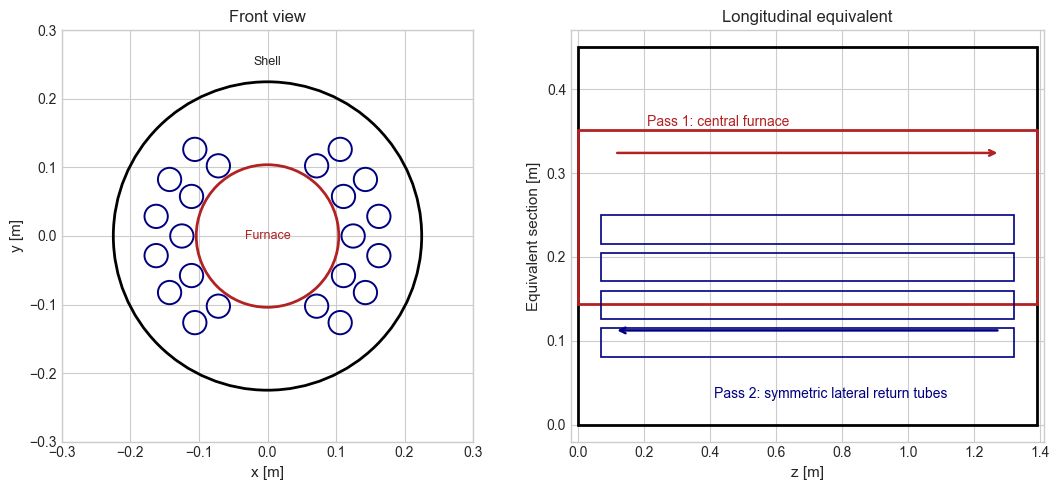

In [5]:
# Draw the nominal simplified geometry and save it to disk.
geometry_figure = draw_geometry(geometry, GEOMETRY_PDF, GEOMETRY_PNG)

# Display the geometry figure inline.
plt.show()


## 6. Energy-balance and conductance graphics

These plots are useful in the pre-report because they show where the thermal power goes and which transfer mechanism controls the exchanger capacity.


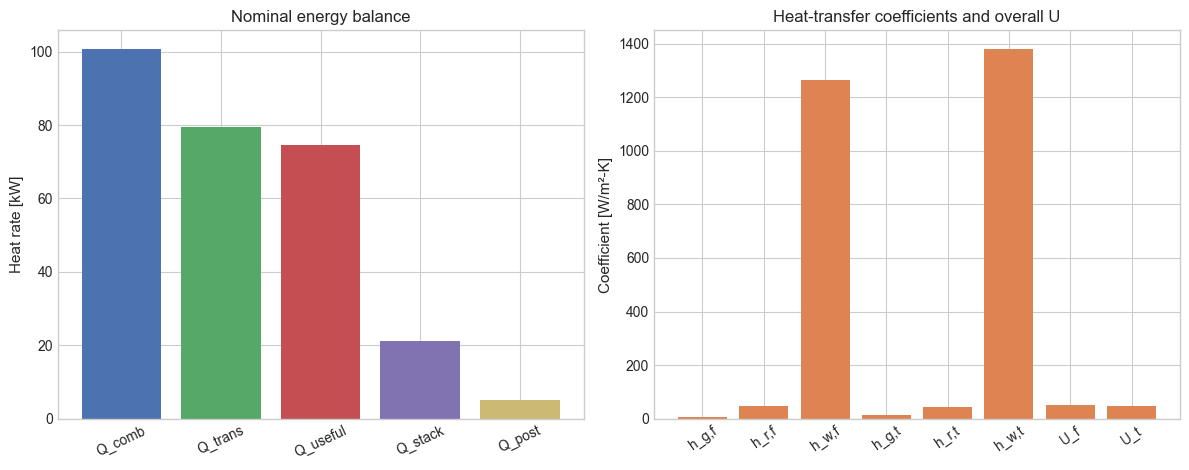

In [6]:
# Create a figure with two subplots for energy balance and coefficient comparison.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# ---------------------------------------------------------------
# Energy-balance plot
# ---------------------------------------------------------------
energy_labels = ["Q_comb", "Q_trans", "Q_useful", "Q_stack", "Q_post"]
energy_values_kw = [
    results["performance"]["q_comb_w"] / 1000.0,
    results["performance"]["q_trans_w"] / 1000.0,
    results["performance"]["q_useful_w"] / 1000.0,
    results["performance"]["q_stack_w"] / 1000.0,
    results["performance"]["q_post_w"] / 1000.0,
]
energy_colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"]

axes[0].bar(energy_labels, energy_values_kw, color=energy_colors)
axes[0].set_title("Nominal energy balance")
axes[0].set_ylabel("Heat rate [kW]")
axes[0].tick_params(axis="x", rotation=25)

# ---------------------------------------------------------------
# Coefficient and UA plot
# ---------------------------------------------------------------
coefficient_labels = ["h_g,f", "h_r,f", "h_w,f", "h_g,t", "h_r,t", "h_w,t", "U_f", "U_t"]
coefficient_values = [
    results["coefficients"]["furnace_gas_convection_w_m2k"],
    results["coefficients"]["furnace_radiation_w_m2k"],
    results["coefficients"]["furnace_water_convection_w_m2k"],
    results["coefficients"]["return_gas_convection_w_m2k"],
    results["coefficients"]["return_radiation_w_m2k"],
    results["coefficients"]["return_water_convection_w_m2k"],
    results["heat_transfer"]["u_furnace_w_m2k"],
    results["heat_transfer"]["u_return_w_m2k"],
]

axes[1].bar(coefficient_labels, coefficient_values, color="#dd8452")
axes[1].set_title("Heat-transfer coefficients and overall U")
axes[1].set_ylabel("Coefficient [W/m²-K]")
axes[1].tick_params(axis="x", rotation=35)

# Tight layout improves readability in the exported notebook.
figure.tight_layout()

# Display the figure.
plt.show()


## 7. Sensitivity study

A pre-report should not only produce one nominal point; it should also show how sensitive the model is to assumptions.  
The next cell varies the excess-air ratio and the return-tube count.


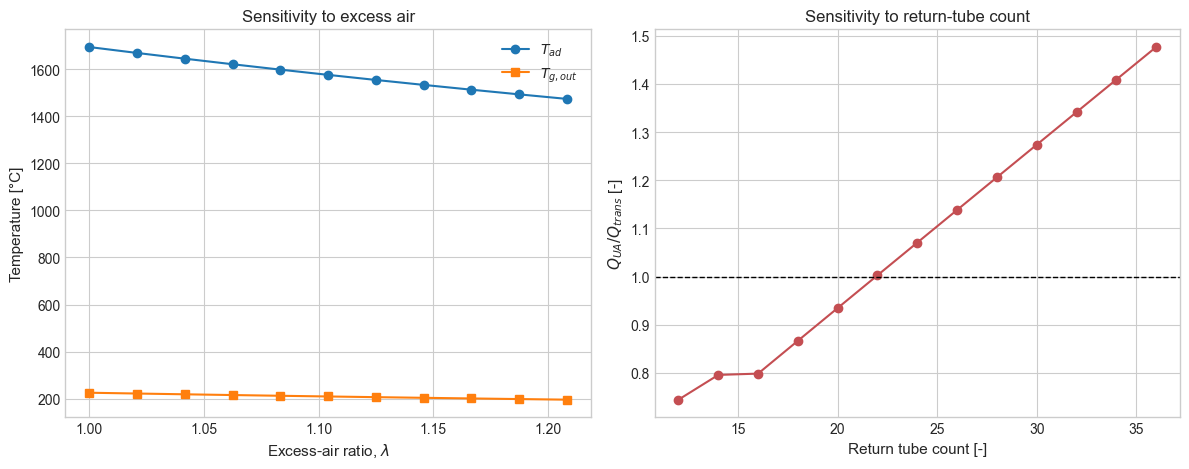

In [7]:
# Create an excess-air ratio vector for the first sensitivity study.
lambda_values = np.linspace(1.00, 1.25, 13)

# Create empty lists that will store the solved temperatures.
tad_values_c = []
flue_values_c = []

# Loop over the excess-air values and solve the nominal model for each case.
for lambda_value in lambda_values:
    # Copy the full parameter dictionary without modifying the original object.
    local_parameters = json.loads(json.dumps(parameters))

    # Update only the excess-air ratio.
    local_parameters["operation"]["excess_air_ratio"] = float(lambda_value)

    # Try to solve the perturbed nominal case.
    try:
        local_results = solve_nominal_case(local_parameters)

        # Store the two temperatures of interest when the case is feasible.
        tad_values_c.append(local_results["combustion"]["t_ad_c"])
        flue_values_c.append(local_results["combustion"]["t_flue_out_c"])
    except ValueError:
        # Store NaN when the assumed nominal heat duty becomes thermodynamically infeasible.
        tad_values_c.append(np.nan)
        flue_values_c.append(np.nan)

# Create a return-tube count vector for the second sensitivity study.
tube_count_values = np.arange(12, 37, 2)

# Create a list to store the UA consistency ratio for each tube-count case.
consistency_values = []

# Loop over the tube-count values.
for tube_count in tube_count_values:
    # Copy the full parameter dictionary without modifying the baseline case.
    local_parameters = json.loads(json.dumps(parameters))

    # Update only the return-tube count.
    local_parameters["geometry"]["return_tube_count"] = int(tube_count)

    # Solve the perturbed case and store the consistency ratio.
    local_results = solve_nominal_case(local_parameters)
    consistency_values.append(local_results["heat_transfer"]["consistency_ratio"])

# Create the sensitivity figure with two panels.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Plot the combustion-temperature sensitivity to excess air.
axes[0].plot(lambda_values, tad_values_c, marker="o", label=r"$T_{ad}$")
axes[0].plot(lambda_values, flue_values_c, marker="s", label=r"$T_{g,out}$")
axes[0].set_xlabel(r"Excess-air ratio, $\lambda$")
axes[0].set_ylabel("Temperature [°C]")
axes[0].set_title("Sensitivity to excess air")
axes[0].legend()

# Plot the consistency ratio versus return-tube count.
axes[1].plot(tube_count_values, consistency_values, marker="o", color="#c44e52")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Return tube count [-]")
axes[1].set_ylabel(r"$Q_{UA}/Q_{trans}$ [-]")
axes[1].set_title("Sensitivity to return-tube count")

# Tight layout improves the final presentation.
figure.tight_layout()

# Display the sensitivity figure.
plt.show()


## 8. Mapping to the laboratory measurements

The last table tells you exactly which measurements from Section 6.2 update which input group in the notebook.


In [8]:
# Build a mapping table between the laboratory measurements and the editable parameters.
measurement_map = pd.DataFrame(
    [
        ("Diameter of gas inlet pipe", "Reference only", "Optional, not used directly in nominal duty"),
        ("Diameter of water inlet pipe", "Reference only", "Optional, not used directly in nominal duty"),
        ("Boiler shell diameter", "geometry.shell_inner_diameter_m", "Replace default shell diameter"),
        ("Furnace inner/outer diameter", "geometry.furnace_inner_diameter_m / geometry.furnace_outer_diameter_m", "Replace default furnace geometry"),
        ("Tube inner/outer diameter", "geometry.return_tube_inner_diameter_m / geometry.return_tube_outer_diameter_m", "Replace default return-tube geometry"),
        ("Boiler depth / tube length", "geometry.shell_length_m / geometry.return_tube_length_m", "Replace default length"),
        ("Number of tubes", "geometry.return_tube_count", "Replace tube-bank count"),
        ("Gas inlet pressure", "Reference for future refinement", "Not used directly in the current nominal model"),
        ("Water inlet pressure", "operation.water_inlet_pressure_bar_abs", "Replace default inlet pressure"),
        ("Steam outlet pressure", "operation.steam_outlet_pressure_bar_abs", "Replace default outlet pressure"),
        ("Water inlet temperature", "operation.water_inlet_temperature_c", "Replace default inlet temperature"),
        ("Steam outlet temperature", "operation.steam_outlet_temperature_c", "Replace default outlet temperature"),
        ("Water flow rate", "Validation target", "Compare against predicted water flow"),
        ("Gas flow rate", "Validation target", "Compare against predicted fuel flow"),
        ("Nitrogen in flue gas", "Validation target", "Compare against dry-basis N2 fraction"),
    ],
    columns=["Measured quantity", "Notebook key", "Action"]
)

# Display the mapping table.
measurement_map


,Measured quantity,Notebook key,Action
0,Diameter of gas inlet pipe,Reference only,"Optional, not used directly in nominal duty"
1,Diameter of water inlet pipe,Reference only,"Optional, not used directly in nominal duty"
2,Boiler shell diameter,geometry.shell_inner_diameter_m,Replace default shell diameter
3,Furnace inner/outer diameter,geometry.furnace_inner_diameter_m / geometry.f...,Replace default furnace geometry
4,Tube inner/outer diameter,geometry.return_tube_inner_diameter_m / geomet...,Replace default return-tube geometry
5,Boiler depth / tube length,geometry.shell_length_m / geometry.return_tube...,Replace default length
6,Number of tubes,geometry.return_tube_count,Replace tube-bank count
7,Gas inlet pressure,Reference for future refinement,Not used directly in the current nominal model
8,Water inlet pressure,operation.water_inlet_pressure_bar_abs,Replace default inlet pressure
9,Steam outlet pressure,operation.steam_outlet_pressure_bar_abs,Replace default outlet pressure
